Импортируйте необходмые библиотеки

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

**Задание 1**

1.Выбрать три датасета из предлагаемых в sklearn (один четко разделимый на кластеры, два других с ярко выраженной нелинейностью).

2.Применить методы Kmeans с разными значениями параметра - количество кластеров, изобразить промежуточные результаты.

3.Подобрать оптимальные параметры метода решатчатым поиском.

4.Провести силуэтный анализ для разных значений параметра- количество кластеров.

5.Использовать альтернативу KMeans (DBSACN, иерархическую кластеризацию). Подсчитать метрики качества с частичной разметкой.


Dataset 1:


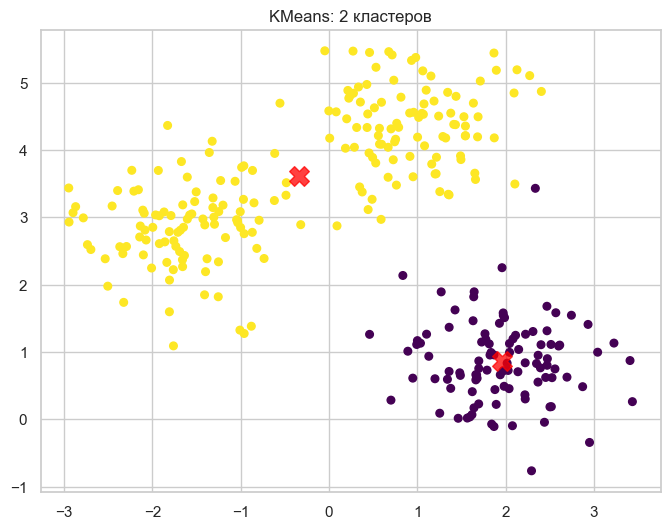

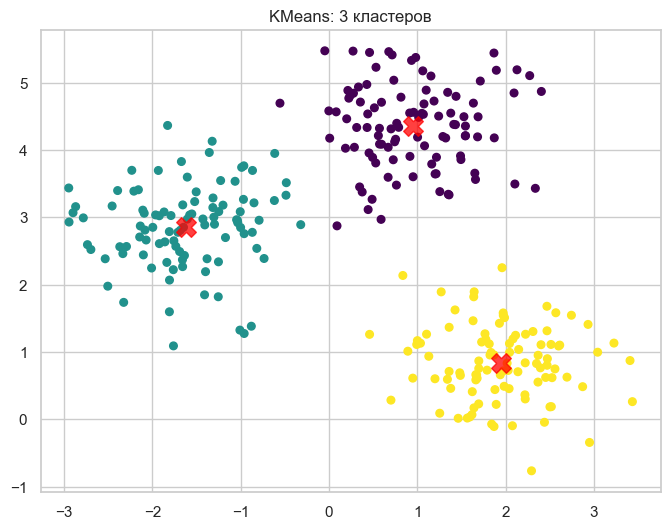

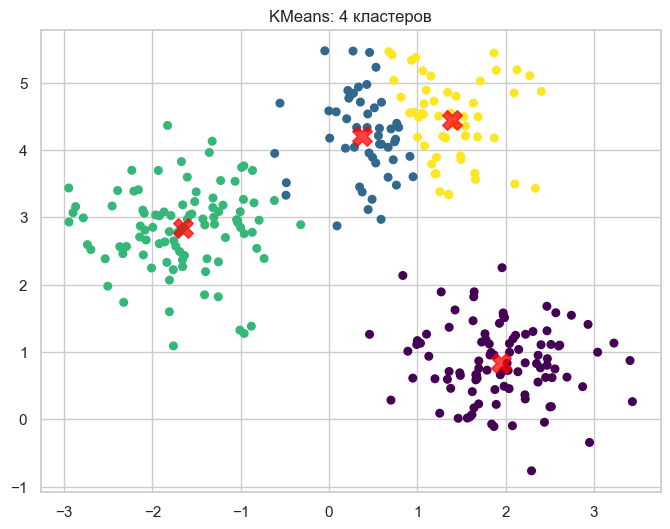

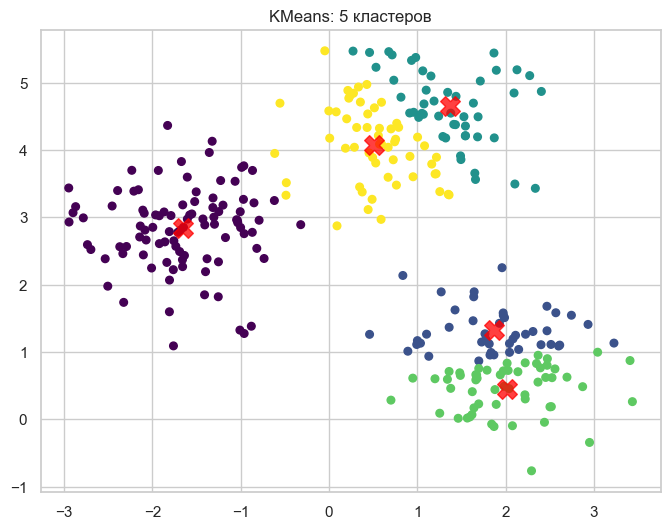


Dataset 2:


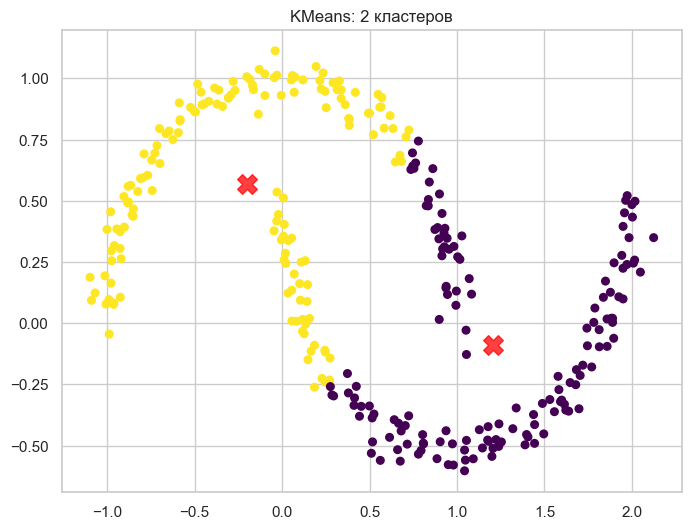

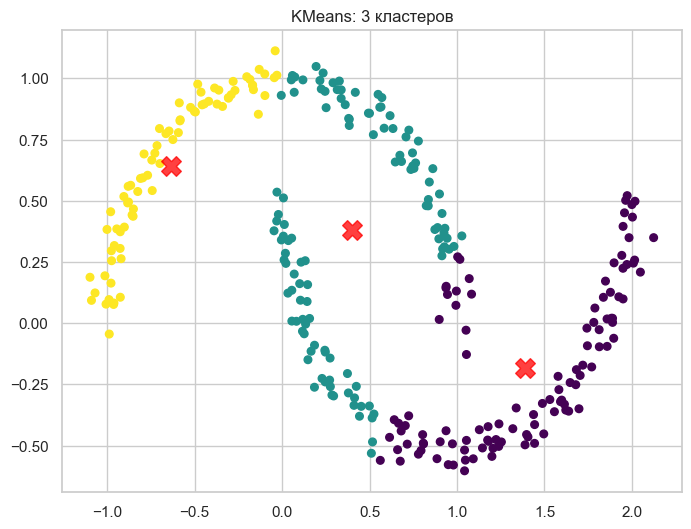

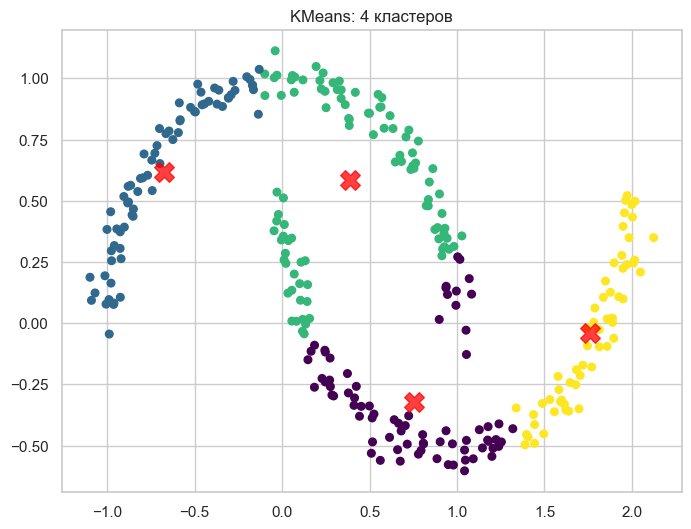

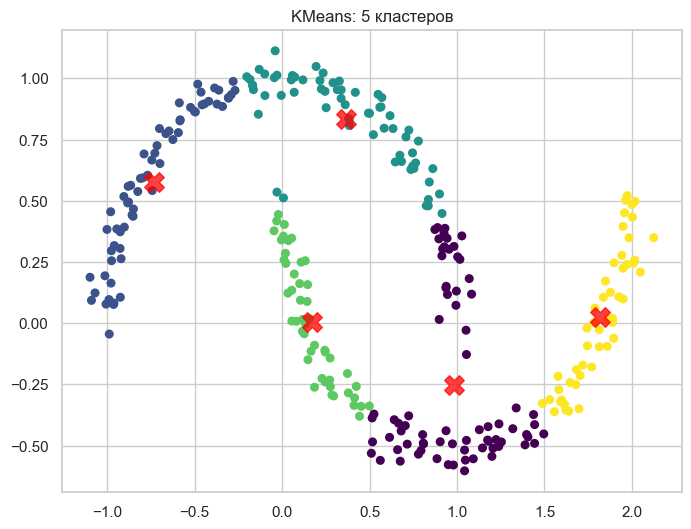


Dataset 3:


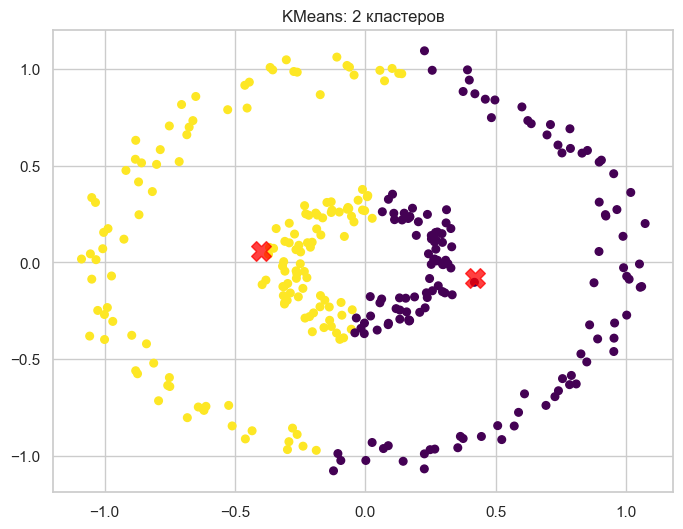

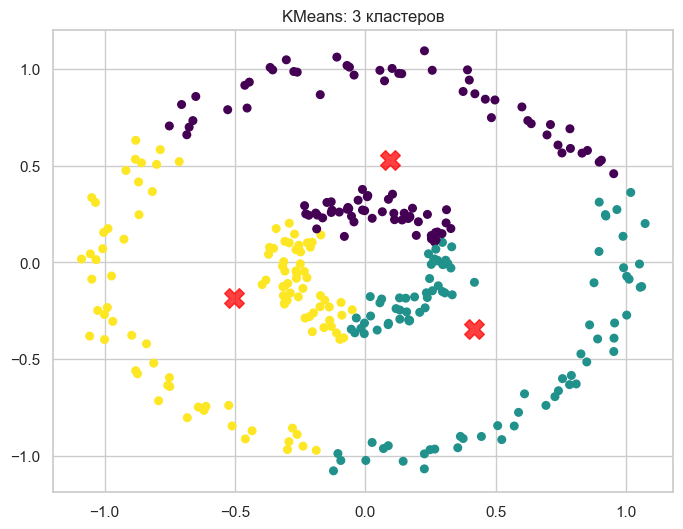

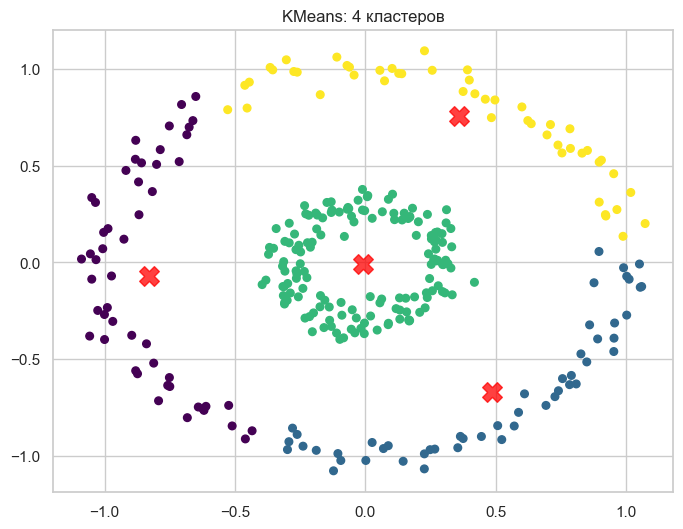

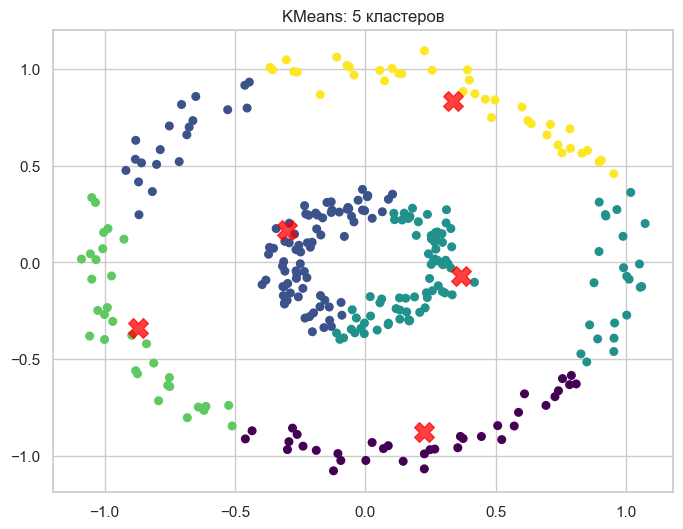

Silhouette Score для {'n_clusters': 2}: 0.5533
Silhouette Score для {'n_clusters': 2}: 0.4887
Silhouette Score для {'n_clusters': 2}: 0.2889
Silhouette Score для {'n_clusters': 3}: 0.6596
Silhouette Score для {'n_clusters': 3}: 0.4010
Silhouette Score для {'n_clusters': 3}: 0.3130
Silhouette Score для {'n_clusters': 4}: 0.5254
Silhouette Score для {'n_clusters': 4}: 0.4481
Silhouette Score для {'n_clusters': 4}: 0.3169
Silhouette Score для {'n_clusters': 5}: 0.3969
Silhouette Score для {'n_clusters': 5}: 0.4824
Silhouette Score для {'n_clusters': 5}: 0.4580
Silhouette Score для {'n_clusters': 6}: 0.4291
Silhouette Score для {'n_clusters': 6}: 0.5050
Silhouette Score для {'n_clusters': 6}: 0.3913
Silhouette Score для {'n_clusters': 7}: 0.4593
Silhouette Score для {'n_clusters': 7}: 0.5245
Silhouette Score для {'n_clusters': 7}: 0.4266
Silhouette Score для {'n_clusters': 8}: 0.3201
Silhouette Score для {'n_clusters': 8}: 0.5283
Silhouette Score для {'n_clusters': 8}: 0.4430
Silhouette Sc

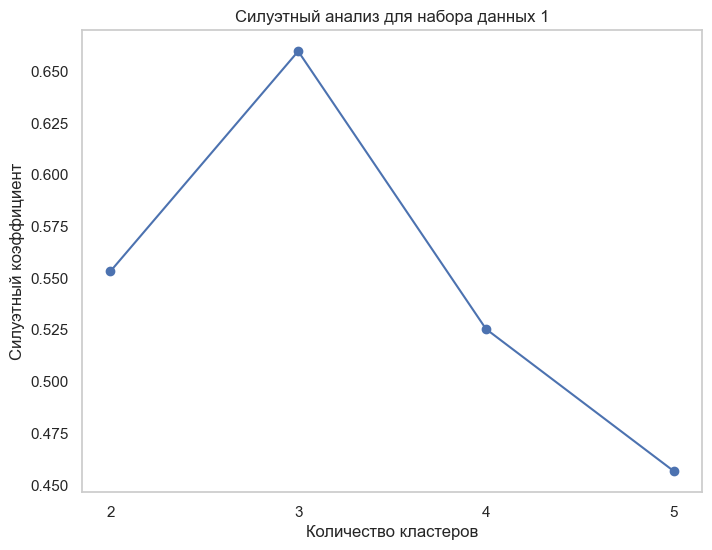

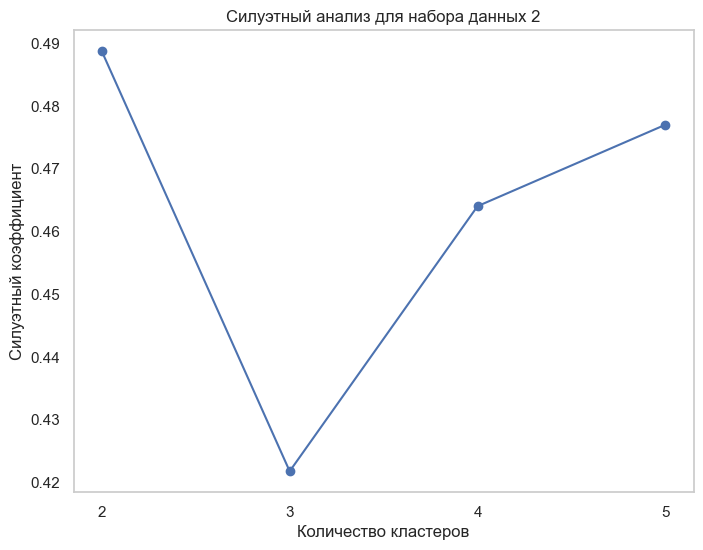

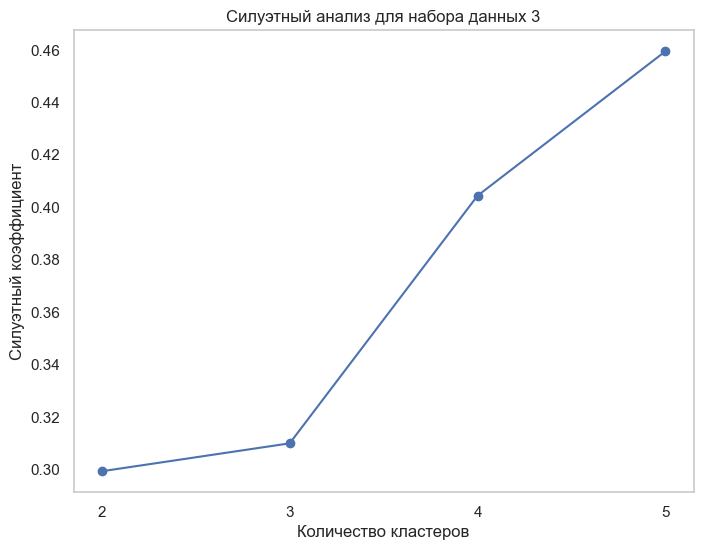


Альтернативные методы кластеризации для набора данных 1


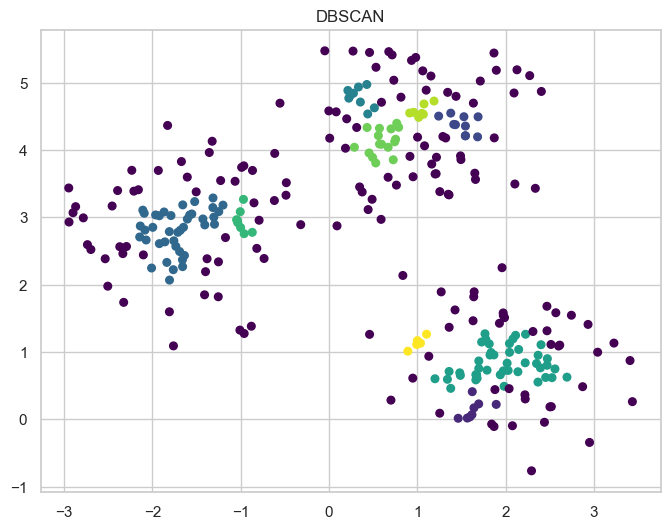

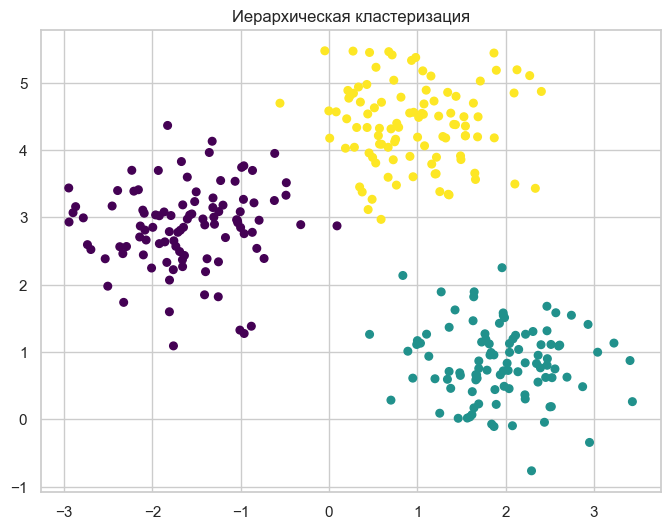

Silhouette Score для DBSCAN: -0.1579

Альтернативные методы кластеризации для набора данных 2


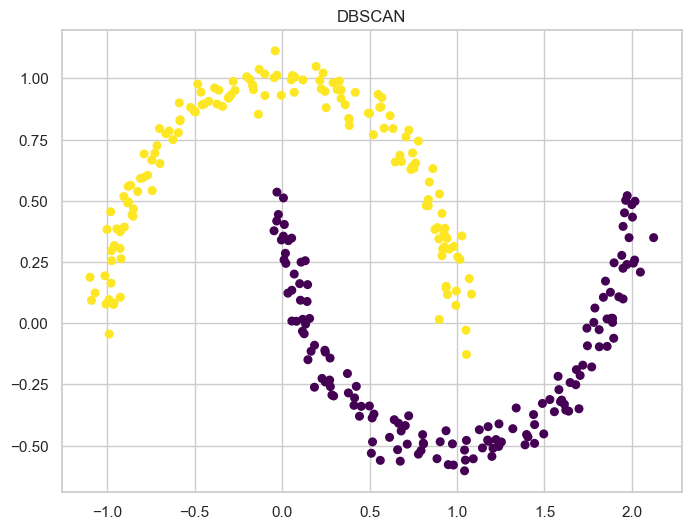

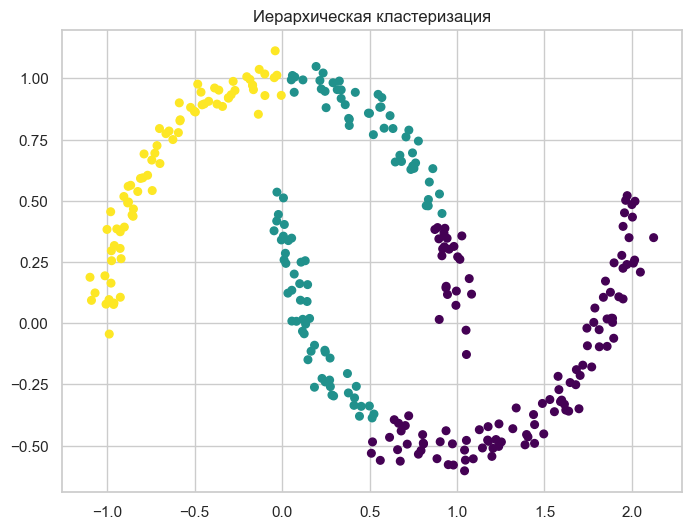

Silhouette Score для иерархической кластеризации: 0.4133

Альтернативные методы кластеризации для набора данных 3


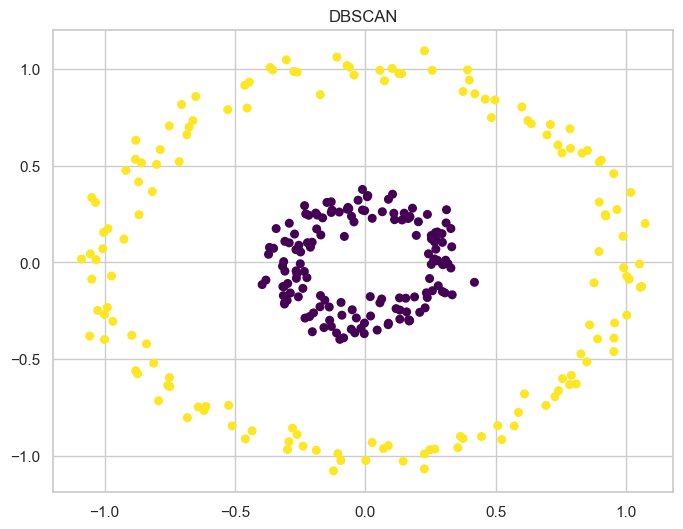

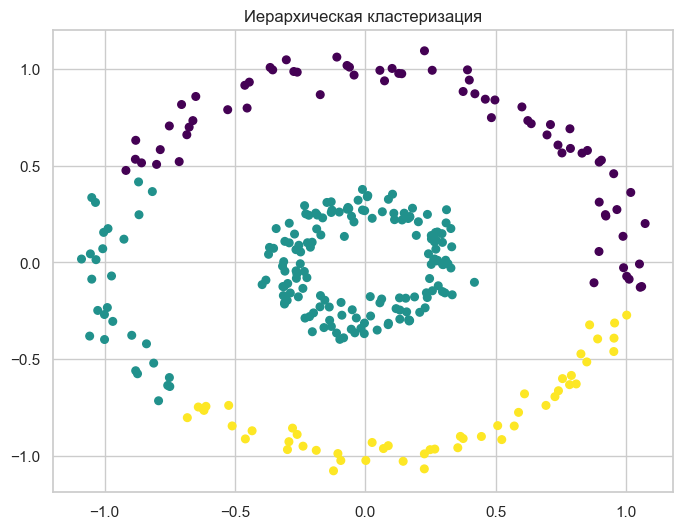

In [3]:
# Установка стилей для графиков, чтобы сделать их визуально привлекательными
sns.set(style='whitegrid')

# Функция для визуализации кластеров, принимающая данные, предсказанные метки и центры кластеров
def plot_clusters(X, y_pred, centers=None, title="Кластеры"):
    # Создаем новую фигуру с заданными размерами
    plt.figure(figsize=(8, 6))
    
    # Строим рассеяние точек данных с использованием предсказанных меток как цветов
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', marker='o')
    
    # Если переданы центры кластеров, мы рисуем их в виде больших красных крестиков
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X') 
        
    # Задаем заголовок графика и показываем его
    plt.title(title)
    plt.show()

# 1. Выбор трех датасетов с различными характеристиками
# Генерируем четко разделимый набор данных с тремя центрами
X1, y1 = datasets.make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Генерируем первый набор нелинейных данных
X2, y2 = datasets.make_moons(n_samples=300, noise=0.05, random_state=0)

# Генерируем второй набор нелинейных данных в форме окружностей
X3, y3 = datasets.make_circles(n_samples=300, noise=0.05, factor=0.3, random_state=0)

# Устанавливаем диапазон значений числа кластеров, которые будем пробовать
n_clusters_options = range(2, 6)

# Итерируемся по датасетам, используя функции zip для параллельной обработки
for i, (X, y_actual) in enumerate(zip([X1, X2, X3], [y1, y2, y3]), start=1):
    print(f"\nDataset {i}:")
    
    # Итерируемся по каждому возможному числу кластеров
    for n_clusters in n_clusters_options:
        # Инициализируем модель KMeans с текущим числом кластеров
        kmeans = KMeans(n_clusters=n_clusters)
        
        # Подгоняем модель и получаем предсказанные метки кластеров
        y_pred = kmeans.fit_predict(X)
        
        # Визуализируем результаты работы KMeans
        plot_clusters(X, y_pred, kmeans.cluster_centers_, title=f"KMeans: {n_clusters} кластеров")

# 3. Подбор оптимальных параметров методом решатчатого поиска с использованием сетки параметров
param_grid = {'n_clusters': range(2, 11)}  # Определяем сетку параметров для n_clusters
best_score = -1  # Инициализируем лучшую оценку
best_params = None  # Инициализируем лучшие параметры

# Перебираем все комбинации параметров для n_clusters
for params in ParameterGrid(param_grid):
    kmeans = KMeans(**params)  # Инициализируем KMeans с текущими параметрами
    # Итерируемся по каждому датасету для оценки
    for X, y_actual in zip([X1, X2, X3], [y1, y2, y3]):
        # Подгоняем модель и получаем предсказанные метки
        y_pred = kmeans.fit_predict(X)
        
        # Вычисляем силуэтный коэффициент для текущего набора данных и параметров
        score = silhouette_score(X, y_pred)
        print(f"Silhouette Score для {params}: {score:.4f}")
        
        # Обновляем лучшие параметры, если текущее значение больше
        if score > best_score:
            best_score = score
            best_params = params

# Печатаем лучшие найденные параметры и их соответствующий силуэтный коэффициент
print(f"\nЛучшие параметры: {best_params} с Silhouette Score: {best_score:.4f}")

# 4. Силуэтный анализ для разных значений параметра - количество кластеров
for i, (X, y_actual) in enumerate(zip([X1, X2, X3], [y1, y2, y3]), start=1):
    silhouette_scores = []  # Список для хранения значений силуэтного коэффициента
    # Пробуем разные числа кластеров
    for n_clusters in n_clusters_options:
        kmeans = KMeans(n_clusters=n_clusters)  # Инициализируем KMeans
        y_pred = kmeans.fit_predict(X)  # Подгоняем и получаем предсказания
        score = silhouette_score(X, y_pred)  # Вычисляем силуэтный коэффициент
        silhouette_scores.append(score)  # Добавляем значение в список

    # Строим график значений силуэтного коэффициента в зависимости от числа кластеров
    plt.figure(figsize=(8, 6))
    plt.plot(n_clusters_options, silhouette_scores, marker='o')
    plt.title(f"Силуэтный анализ для набора данных {i}")
    plt.xlabel('Количество кластеров')  # Подписываем ось X
    plt.ylabel('Силуэтный коэффициент')  # Подписываем ось Y
    plt.xticks(n_clusters_options)  # Устанавливаем метки для оси X
    plt.grid()  # Включаем сетку для графика
    plt.show()  # Показываем график

# 5. Альтернатива KMeans: DBSCAN и иерархическая кластеризация
for i, (X, y_actual) in enumerate(zip([X1, X2, X3], [y1, y2, y3]), start=1):
    print(f"\nАльтернативные методы кластеризации для набора данных {i}")

    # Применяем алгоритм DBSCAN
    dbscan = DBSCAN(eps=0.2, min_samples=5)  # Инициализируем DBSCAN с заданными параметрами
    y_pred_dbscan = dbscan.fit_predict(X)  # Подгоняем и получаем предсказания
    plot_clusters(X, y_pred_dbscan, title='DBSCAN')  # Визуализируем результаты DBSCAN

    # Применяем иерархическую кластеризацию
    hierarchical = AgglomerativeClustering(n_clusters=3)  # Инициализируем иерархическую кластеризацию
    y_pred_hc = hierarchical.fit_predict(X)  # Подгоняем и получаем предсказания
    plot_clusters(X, y_pred_hc, title='Иерархическая кластеризация')  # Визуализируем результаты

    # Оценка качества (например, Silhouette Score) с частичной разметкой
    if i == 1:  # Если это четко разделимый датасет
        score_kmeans = silhouette_score(X, y_pred_dbscan)  # Вычисляем силуэтный коэффициент для DBSCAN
        print(f"Silhouette Score для DBSCAN: {score_kmeans:.4f}")

    if i == 2:  # Если это нелинейный датасет 1
        score_hc = silhouette_score(X, y_pred_hc)  # Вычисляем силуэтный коэффициент для иерархической кластеризации
        print(f"Silhouette Score для иерархической кластеризации: {score_hc:.4f}")

Лучшие параметры для луны: {'n_clusters': 2} с Silhouette Score: 0.4887


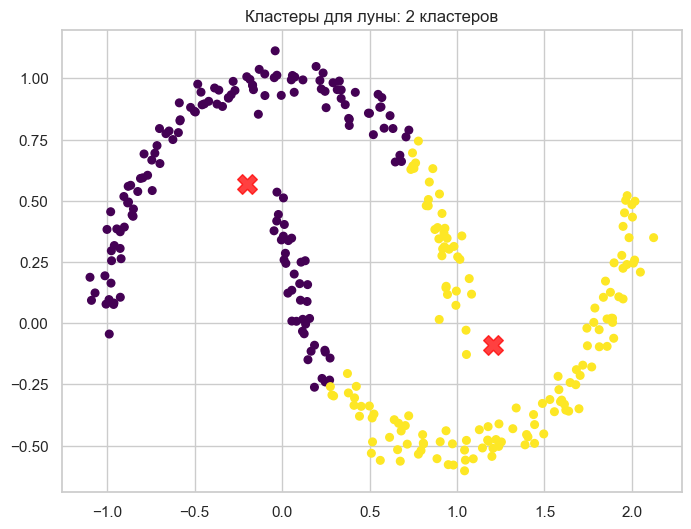

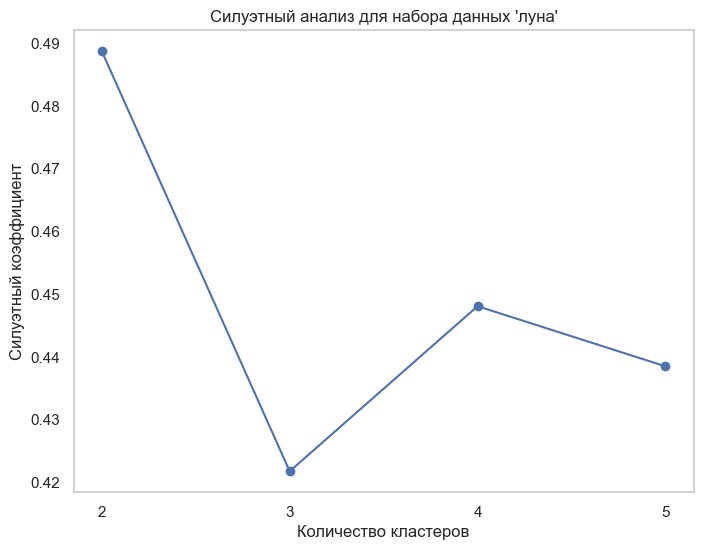

In [8]:
# Установка стилей для графиков, чтобы сделать их визуально привлекательными
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid

# Задаем стиль
sns.set(style='whitegrid')

# Функция для визуализации кластеров
def plot_clusters(X, y_pred, centers=None, title="Кластеры"):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', marker='o')
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
    plt.title(title)
    plt.show()

# Генерация набора данных "луна"
X2, y2 = datasets.make_moons(n_samples=300, noise=0.05, random_state=0)

# Подбор оптимального числа кластеров
best_score = -1
best_params = None

# Инициализируем список для хранения результатов силуэтных коэффициентов
n_clusters_options = range(2, 6)
silhouette_scores = []

# Итерируемся по количеству кластеров для силуэтного анализа
for n_clusters in n_clusters_options:
    kmeans = KMeans(n_clusters=n_clusters)
    y_pred = kmeans.fit_predict(X2)
    
    # Рассчитываем силуэтный коэффициент
    score = silhouette_score(X2, y_pred)
    silhouette_scores.append(score)
    
    # Сохраняем лучшие параметры
    if score > best_score:
        best_score = score
        best_params = {'n_clusters': n_clusters}

# Вывод лучших параметров и соответствующего силуэтного коэффициента
print(f"Лучшие параметры для луны: {best_params} с Silhouette Score: {best_score:.4f}")

# Визуализируем кластеры для лучшего числа кластеров
kmeans_best = KMeans(n_clusters=best_params['n_clusters'])
y_pred_best = kmeans_best.fit_predict(X2)
plot_clusters(X2, y_pred_best, kmeans_best.cluster_centers_, title=f"Кластеры для луны: {best_params['n_clusters']} кластеров")

# Построение графика силуэтного анализа
plt.figure(figsize=(8, 6))
plt.plot(n_clusters_options, silhouette_scores, marker='o')
plt.title("Силуэтный анализ для набора данных 'луна'")
plt.xlabel('Количество кластеров')
plt.ylabel('Силуэтный коэффициент')
plt.xticks(n_clusters_options)
plt.grid()
plt.show()

**Задание 2**

1.Сгенерировать свой многомерный набор данных с некоторой структурой. Изобразить проекцию на плоскости. Применить метод PCA. Проанализировать качество.

2.Выбрать три датасета из предлагаемых в sklearn. Применить к этим датасетам класический  PCA и два альтернативных метода. Проиллюстрировать результат.

3.Применить t-SNE для любого выбранного датасета с выраженной нелинейностью, подобрав параметры. Изобразить результат.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, load_iris, load_wine, load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

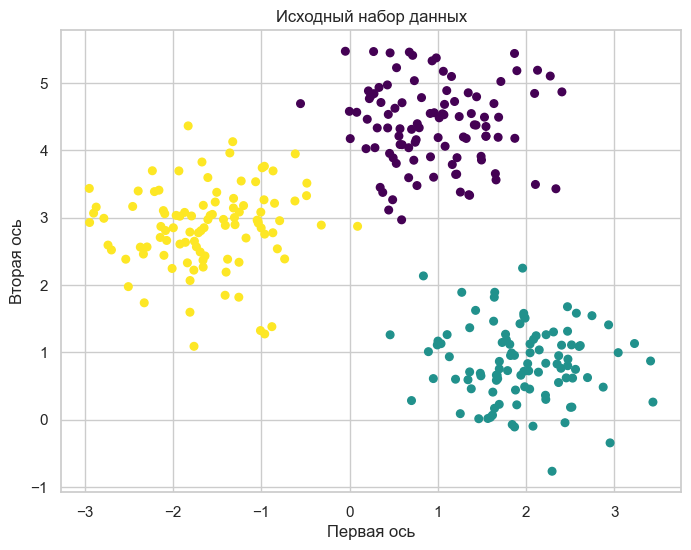

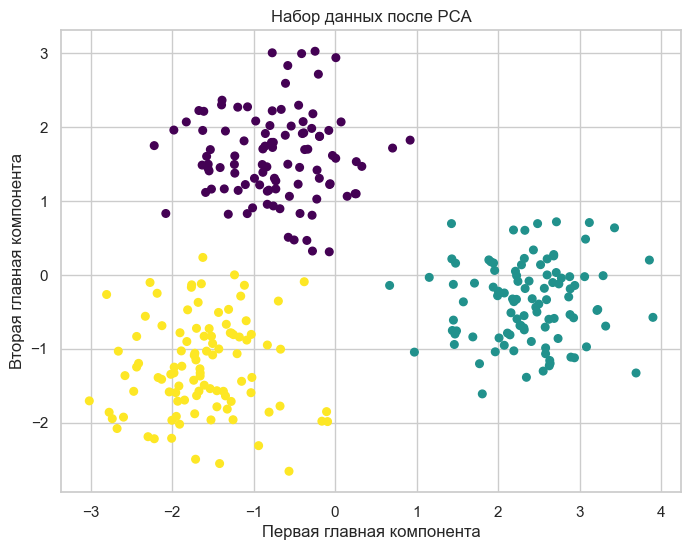

Доля объясненной дисперсии: [0.65182147 0.34817853]


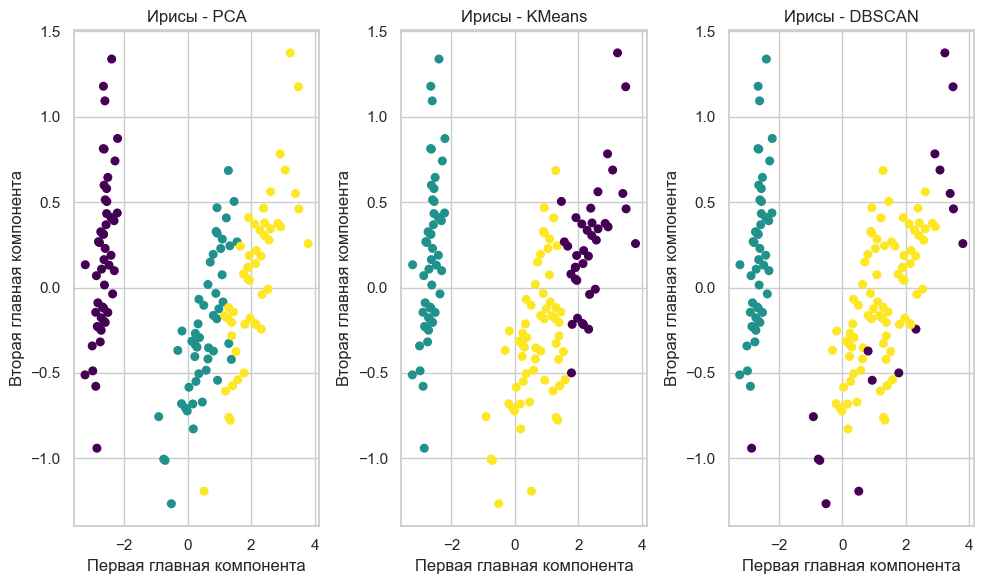

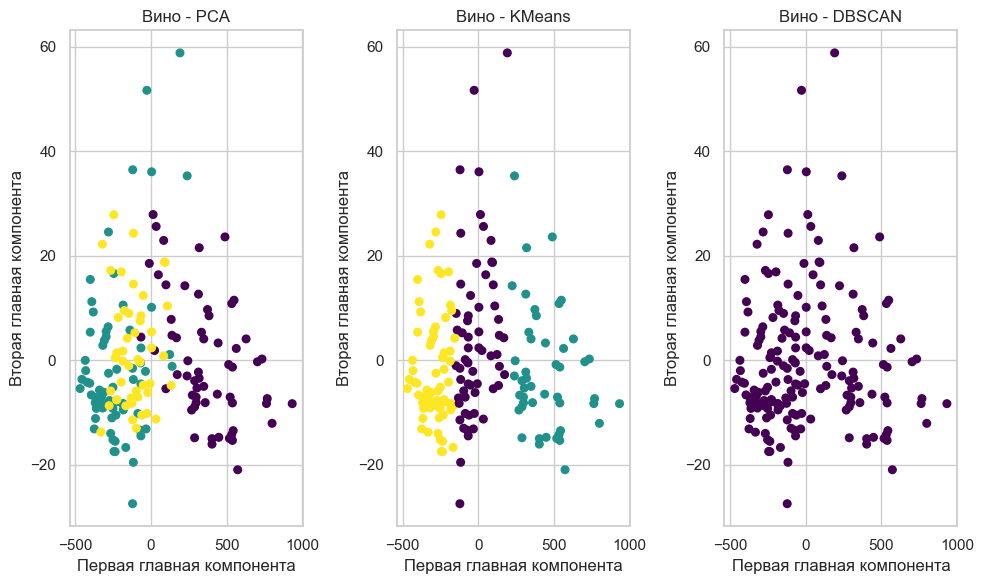

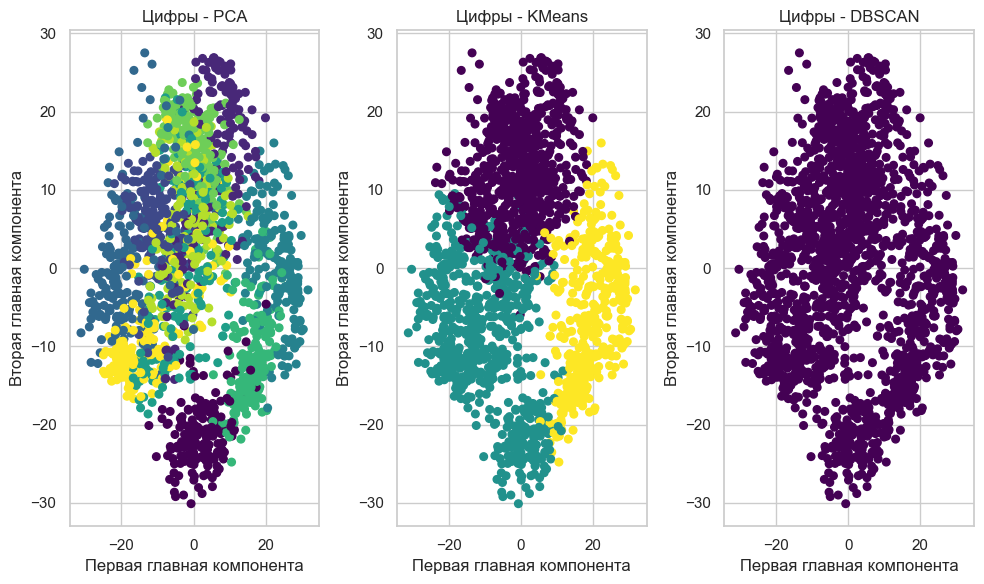

c:\Users\sbelova\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


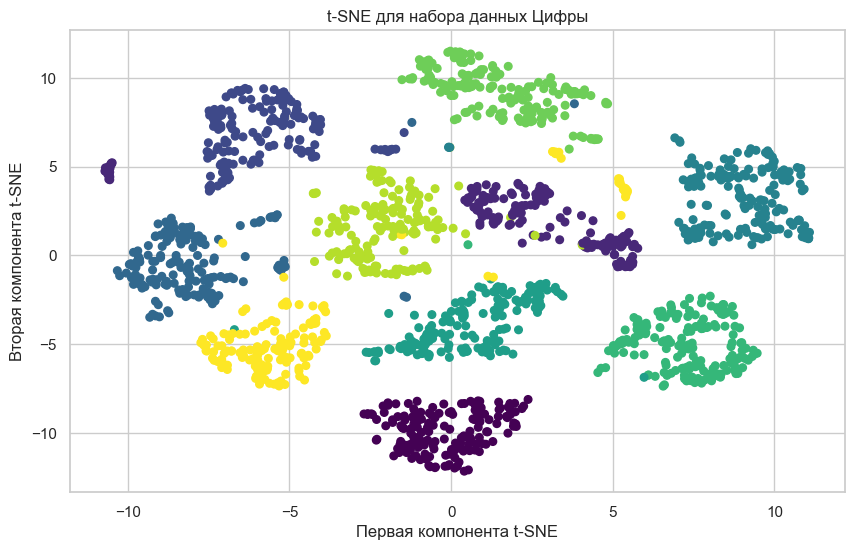

In [7]:
# 1. Генерация многомерного набора данных с некоторой структурой
# Создаем набор данных с 3 кластерами, состоящими из 300 образцов, с заданным стандартным отклонением
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Визуализация оригинальных данных
# Настраиваем размер графика
plt.figure(figsize=(8, 6))
# Строим точечный график (scatter plot) для массива X с цветами y, размером точек 30 и цветовой картой 'viridis'
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis')
plt.title('Исходный набор данных')  # Добавляем заголовок к графику
plt.xlabel('Первая ось')  # Подписываем ось X
plt.ylabel('Вторая ось')  # Подписываем ось Y
plt.show()  # Отображаем график

# Применение PCA (Метод главных компонент)
# Инициализируем PCA с двумя компонентами
pca = PCA(n_components=2)
# Применяем PCA к нашим данным X и сохраняем результат в X_pca
X_pca = pca.fit_transform(X)

# Визуализация данных после PCA
# Настраиваем размер нового графика
plt.figure(figsize=(8, 6))
# Строим точечный график для пониженной размерности X_pca
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=30, cmap='viridis')
plt.title('Набор данных после PCA')  # Заголовок для графика с результатами PCA
plt.xlabel('Первая главная компонента')  # Подписываем ось X
plt.ylabel('Вторая главная компонента')  # Подписываем ось Y
plt.show()  # Отображаем график

# Анализ качества
# Получаем доли объясненной дисперсии для каждой из компонент PCA
explained_variance = pca.explained_variance_ratio_
# Печатаем информацию о доле объясненной дисперсии
print(f"Доля объясненной дисперсии: {explained_variance}")

# 2. Выбор трех датасетов и применение их к классическому PCA и два альтернативных метода
# Загружаем три различных набора данных: ирисы, вино и цифры
datasets = {
    "Ирисы": load_iris(),
    "Вино": load_wine(),
    "Цифры": load_digits()
}

# Проходим с помощью цикла по каждому набору данных
for dataset_name, dataset in datasets.items():
    X = dataset.data  # Извлекаем данные (признаки) из набора
    y = dataset.target  # Извлекаем целевые метки

    # PCA
    # Инициализируем PCA с двумя компонентами
    pca = PCA(n_components=2)
    # Применяем PCA к данным X
    X_pca = pca.fit_transform(X)

    # Настраиваем график для визуализации PCA
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 3, 1)  # Разбиваем график на 1 строку и 3 столбца, выбирая первый для PCA
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=30)
    plt.title(f'{dataset_name} - PCA')  # Заголовок для графика PCA
    plt.xlabel('Первая главная компонента')  # Подписываем ось X
    plt.ylabel('Вторая главная компонента')  # Подписываем ось Y

    # KMeans
    # Инициализируем KMeans с 3 кластерами
    kmeans = KMeans(n_clusters=3)
    # Применяем KMeans к данным X и получаем метки кластеров
    y_kmeans = kmeans.fit_predict(X)
    # Применяем PCA к данным X для визуализации
    X_kmeans_pca = pca.fit_transform(X)

    plt.subplot(1, 3, 2)  # Выбираем второй субграфик для KMeans
    plt.scatter(X_kmeans_pca[:, 0], X_kmeans_pca[:, 1], c=y_kmeans, cmap='viridis', s=30)
    plt.title(f'{dataset_name} - KMeans')  # Заголовок для графика KMeans
    plt.xlabel('Первая главная компонента')  # Подписываем ось X
    plt.ylabel('Вторая главная компонента')  # Подписываем ось Y

    # DBSCAN
    # Инициализируем DBSCAN с eps=0.5 и min_samples=5
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    # Применяем DBSCAN к данным X для получения меток кластеров
    y_dbscan = dbscan.fit_predict(X)
    # Применяем PCA для визуализации данных
    X_dbscan_pca = pca.fit_transform(X)

    plt.subplot(1, 3, 3)  # Выбираем третий субграфик для DBSCAN
    plt.scatter(X_dbscan_pca[:, 0], X_dbscan_pca[:, 1], c=y_dbscan, cmap='viridis', s=30)
    plt.title(f'{dataset_name} - DBSCAN')  # Заголовок для графика DBSCAN
    plt.xlabel('Первая главная компонента')  # Подписываем ось X
    plt.ylabel('Вторая главная компонента')  # Подписываем ось Y

    plt.tight_layout()  # Оптимизируем расположение подграфиков для лучшей визуализации
    plt.show()  # Отображаем графики

# 3. Применение t-SNE для датасета с выраженной нелинейностью
# Выбираем набор данных "Цифры"
X_digits, y_digits = load_digits(return_X_y=True)

# Применяем t-SNE
# Инициализируем t-SNE для уменьшения размерности до 2 с перплексией 30 и 300 итерациями
tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
# Применяем t-SNE к набору данных цифр
X_tsne = tsne.fit_transform(X_digits)

# Визуализация t-SNE
# Настраиваем размер графика
plt.figure(figsize=(10, 6))
# Строим график для данных после t-SNE
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap='viridis', s=30)
plt.title('t-SNE для набора данных Цифры')  # Заголовок для графика t-SNE
plt.xlabel('Первая компонента t-SNE')  # Подписываем ось X
plt.ylabel('Вторая компонента t-SNE')  # Подписываем ось Y
plt.show()  # Отображаем график

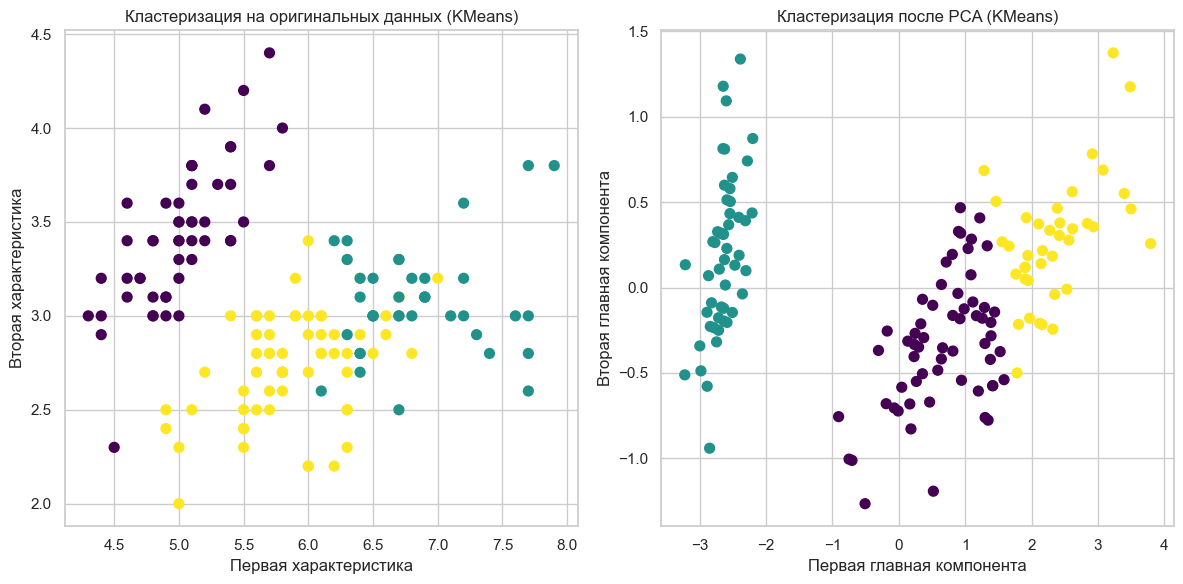

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Загружаем набор данных ирисы
iris = load_iris()
X = iris.data
y = iris.target

# 1. Кластеризация на оригинальных данных с использованием KMeans
kmeans_original = KMeans(n_clusters=3)
y_kmeans_original = kmeans_original.fit_predict(X)

# 2. Применение PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Кластеризация на данных после PCA с использованием KMeans
kmeans_pca = KMeans(n_clusters=3)
y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# 4. Визуализация результатов
plt.figure(figsize=(12, 6))

# Подграфик 1: Оригинальные данные
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans_original, cmap='viridis', s=50)
plt.title('Кластеризация на оригинальных данных (KMeans)')
plt.xlabel('Первая характеристика')
plt.ylabel('Вторая характеристика')

# Подграфик 2: Данные после PCA
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans_pca, cmap='viridis', s=50)
plt.title('Кластеризация после PCA (KMeans)')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')

plt.tight_layout()
plt.show()